<a href="https://colab.research.google.com/github/rachna7063/My-_Project-_work/blob/main/Income_data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix



I have import all the required libraries for data analysis.

In [3]:
# 1. Importing data with missing values properly parsed
# Adjusted path slightly in case of formatting issues
data_income = pd.read_csv('/content/income(1).csv', na_values=[" ?", 'NaN', '?'])
print(data_income)


       zage       JobType         EdType        maritalstatus  \
0        45       Private        HS-grad             Divorced   
1        24   Federal-gov        HS-grad        Never-married   
2        44       Private   Some-college   Married-civ-spouse   
3        27       Private            9th        Never-married   
4        20       Private   Some-college        Never-married   
...     ...           ...            ...                  ...   
31973    34     Local-gov        HS-grad        Never-married   
31974    34     Local-gov   Some-college        Never-married   
31975    23       Private   Some-college   Married-civ-spouse   
31976    42     Local-gov   Some-college   Married-civ-spouse   
31977    29       Private      Bachelors        Never-married   

             occupation     relationship    race   gender  capitalgain  \
0          Adm-clerical    Not-in-family   White   Female            0   
1          Armed-Forces        Own-child   White     Male            0 

WOW! i have imported the income data Successfull...

In [15]:
# Create a copy for exploration
data = data_income.copy()



To avoid errors and  corruption  in main data i have just created a copy  of data for analysis.

In [17]:
data.rename(columns={'zage': 'age'}, inplace=True)


i have rename  the column name "zage" as "age"

In [18]:
# 2. Exploratory Data Analysis & Handling Missing Values
print("--- Data Info ---")
print(data.info())



--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31978 entries, 0 to 31977
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   age            31978 non-null  int64 
 1   JobType        30169 non-null  object
 2   EdType         31978 non-null  object
 3   maritalstatus  31978 non-null  object
 4   occupation     30162 non-null  object
 5   relationship   31978 non-null  object
 6   race           31978 non-null  object
 7   gender         31978 non-null  object
 8   capitalgain    31978 non-null  int64 
 9   capitalloss    31978 non-null  int64 
 10  hoursperweek   31978 non-null  int64 
 11  nativecountry  31978 non-null  object
 12  SalStat        31978 non-null  object
dtypes: int64(4), object(9)
memory usage: 3.2+ MB
None


Here i have got all the details regarding columns Data type. How much memory has been used . Numbers of rows and columns etc.

In [19]:
print("\n--- Missing Values Count ---")
print(data.isnull().sum())




--- Missing Values Count ---
age                 0
JobType          1809
EdType              0
maritalstatus       0
occupation       1816
relationship        0
race                0
gender              0
capitalgain         0
capitalloss         0
hoursperweek        0
nativecountry       0
SalStat             0
dtype: int64


Check the missing value so i am seeing here that total missing value in (job type) column is 1809 and (occupation) column is 1816.

In [20]:
# Dropping ROWS with missing values completely to preserve columns
data2 = data.dropna(axis=0)
print(f"\nShape after dropping missing rows: {data2.shape}")




Shape after dropping missing rows: (30162, 13)


In [21]:
# Correlation matrix on numeric columns
numeric_data2 = data2.select_dtypes(include=np.number)
correlation = numeric_data2.corr()
print("\n--- Numerical Correlation Matrix ---")
print(correlation)




--- Numerical Correlation Matrix ---
                   age  capitalgain  capitalloss  hoursperweek
age           1.000000     0.080154     0.060165      0.101599
capitalgain   0.080154     1.000000    -0.032229      0.080432
capitalloss   0.060165    -0.032229     1.000000      0.052417
hoursperweek  0.101599     0.080432     0.052417      1.000000


checking correlation matrix

**Data Visualization**

In [22]:
# 3. Data Visualization
# Gender vs Salary Status
gender_salstatus = pd.crosstab(index=data2["gender"], columns=data2["SalStat"], margins=True, normalize='index')
print("\n--- Gender vs Salary Status Cross-tab ---")
print(gender_salstatus)




--- Gender vs Salary Status Cross-tab ---
SalStat  greater than 50,000  less than or equal to 50,000
gender                                                    
 Female             0.113678                      0.886322
 Male               0.313837                      0.686163
All                 0.248922                      0.751078


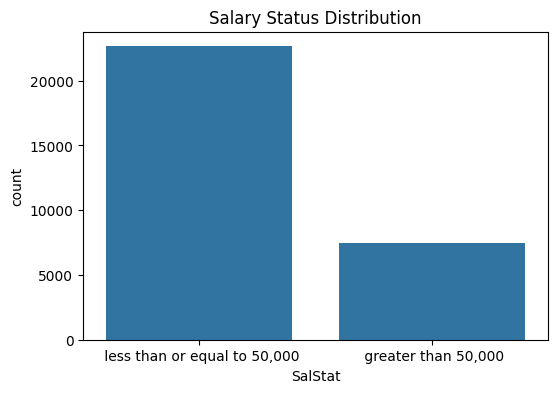

In [23]:
# Visual plots
plt.figure(figsize=(6, 4))
sns.countplot(data=data2, x='SalStat')
plt.title("Salary Status Distribution")
plt.show()



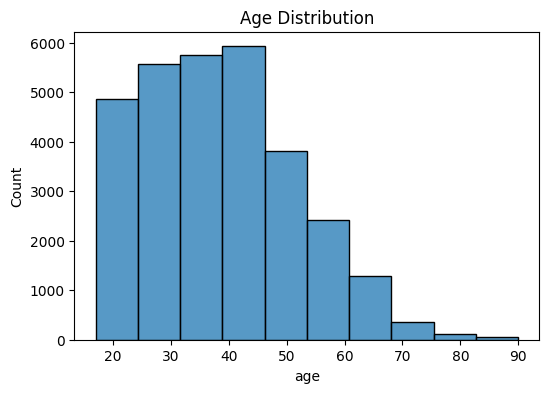

In [25]:
plt.figure(figsize=(6, 4))
sns.histplot(data=data2, x="age", bins=10, kde=False)
plt.title("Age Distribution")
plt.show()



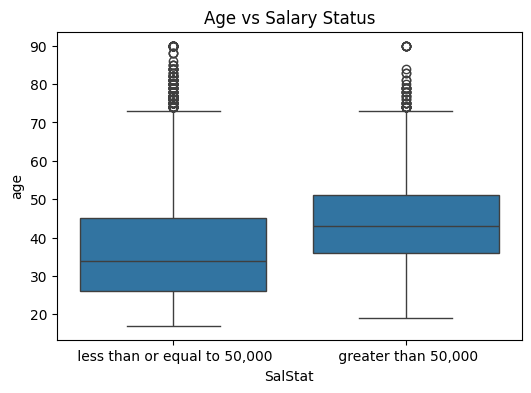

In [26]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='SalStat', y='age', data=data2)
plt.title("Age vs Salary Status")
plt.show()



In [27]:
# 4. Target Mapping
# Stripping whitespaces to make sure string matching is reliable
data2['SalStat'] = data2['SalStat'].str.strip().map({'less than or equal to 50,000': 0, 'greater than 50,000': 1})



/tmp/ipykernel_779/739345386.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data2['SalStat'] = data2['SalStat'].str.strip().map({'less than or equal to 50,000': 0, 'greater than 50,000': 1})


In [28]:
# Fallback check just in case string matching fails or maps to NaN
if data2['SalStat'].isnull().any():
    print("Warning: Remapping resulted in NaNs. Dropping remaining missing target rows.")
    data2 = data2.dropna(subset=['SalStat'])



In [29]:
 #==========================================
# MODEL 1: Logistic Regression (All Features)
# ==========================================
print("\n=== MODEL 1: Logistic Regression (All Features) ===")




=== MODEL 1: Logistic Regression (All Features) ===


In [30]:
# One-hot encoding categorical variables
new_data1 = pd.get_dummies(data2.drop('SalStat', axis=1), drop_first=True)

X1 = new_data1.values
y1 = data2['SalStat'].values



In [31]:
# Split data
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.3, random_state=0)



In [32]:
# Scale continuous features if necessary, but continuing with your logistic setup:
logistic_model1 = LogisticRegression(max_iter=1000) # Increased max_iter for convergence
logistic_model1.fit(X1_train, y1_train)



/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [33]:
# Predictions & Metrics
pred1 = logistic_model1.predict(X1_test)
cm1 = confusion_matrix(y1_test, pred1)
acc1 = accuracy_score(y1_test, pred1)

print("Confusion Matrix:\n", cm1)
print(f"Accuracy Score: {acc1:.4f}")
print(f"Misclassified samples: {(y1_test != pred1).sum()}")




Confusion Matrix:
 [[6317  506]
 [ 910 1316]]
Accuracy Score: 0.8435
Misclassified samples: 1416


In [34]:
# ==========================================
# MODEL 2: Logistic Regression (Selected Features)
# ==========================================
print("\n=== MODEL 2: Logistic Regression (Selected Features) ===")

cols_to_drop = ['gender', 'nativecountry', 'race', 'SalStat']
new_data2 = data2.drop(cols_to_drop, axis=1)
new_data2 = pd.get_dummies(new_data2, drop_first=True)

X2 = new_data2.values
y2 = data2['SalStat'].values




=== MODEL 2: Logistic Regression (Selected Features) ===


In [35]:
# Split data
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.3, random_state=0)

logistic_model2 = LogisticRegression(max_iter=1000)
logistic_model2.fit(X2_train, y2_train)



/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [36]:
# Predictions & Metrics
pred2 = logistic_model2.predict(X2_test)
cm2 = confusion_matrix(y2_test, pred2)
acc2 = accuracy_score(y2_test, pred2)

print("Confusion Matrix:\n", cm2)
print(f"Accuracy Score: {acc2:.4f}")
print(f"Misclassified samples: {(y2_test != pred2).sum()}")




Confusion Matrix:
 [[6332  491]
 [ 929 1297]]
Accuracy Score: 0.8431
Misclassified samples: 1420


In [37]:
# ==========================================
# MODEL 3: K-Nearest Neighbors (KNN)
# ==========================================
print("\n=== MODEL 3: KNN Classifier ===")

# Corrected: Fitting on train data, predicting on test data
knn_classifier = KNeighborsClassifier(n_neighbors=5)
knn_classifier.fit(X2_train, y2_train)

pred_knn = knn_classifier.predict(X2_test)
cm_knn = confusion_matrix(y2_test, pred_knn)
acc_knn = accuracy_score(y2_test, pred_knn)

print("Confusion Matrix:\n", cm_knn)
print(f"Accuracy Score: {acc_knn:.4f}")
print(f"Misclassified samples: {(y2_test != pred_knn).sum()}")




=== MODEL 3: KNN Classifier ===
Confusion Matrix:
 [[6227  596]
 [ 844 1382]]
Accuracy Score: 0.8409
Misclassified samples: 1440


In [38]:
# Effect of K-values on performance
print("\n--- Tuning K-values ---")
misclassified_samples = []

for k in range(1, 11):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X2_train, y2_train)
    pred_k = knn.predict(X2_test)
    num_missed = (y2_test != pred_k).sum()
    misclassified_samples.append(num_missed)
    print(f"K = {k} | Misclassified samples: {num_missed}")



--- Tuning K-values ---
K = 1 | Misclassified samples: 1753
K = 2 | Misclassified samples: 1514
K = 3 | Misclassified samples: 1543
K = 4 | Misclassified samples: 1458
K = 5 | Misclassified samples: 1440
K = 6 | Misclassified samples: 1423
K = 7 | Misclassified samples: 1459
K = 8 | Misclassified samples: 1456
K = 9 | Misclassified samples: 1454
K = 10 | Misclassified samples: 1443
